Using Device: cpu

Training with SGD + Momentum
Epoch 1: Loss = 2.0683, Accuracy = 25.02%
Epoch 2: Loss = 1.7987, Accuracy = 36.92%
Epoch 3: Loss = 1.6617, Accuracy = 42.24%

Training with Adam
Epoch 1: Loss = 1.9052, Accuracy = 32.56%
Epoch 2: Loss = 1.5837, Accuracy = 43.12%
Epoch 3: Loss = 1.4573, Accuracy = 49.88%


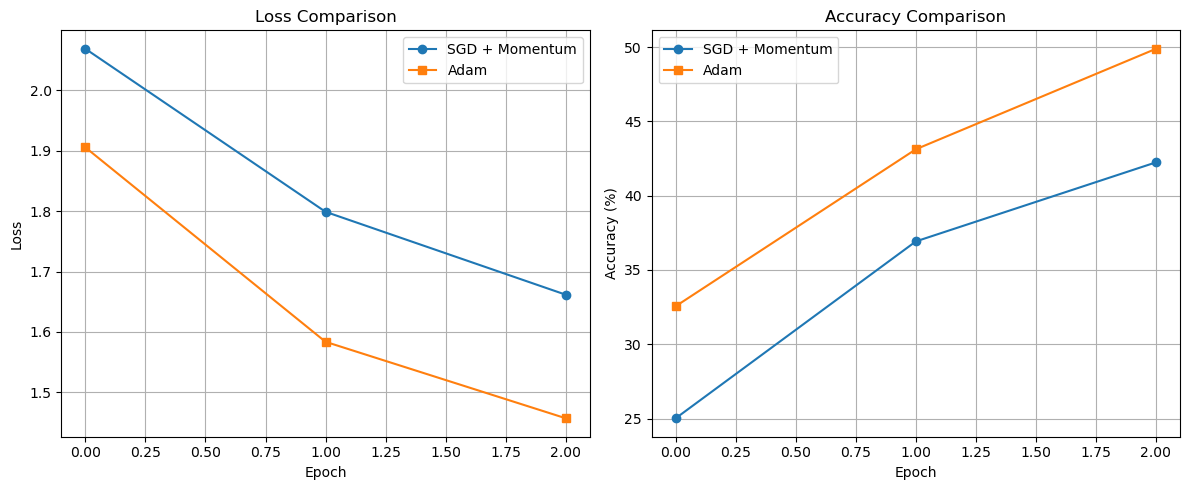

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import Subset

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

# Dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Use only first 5000 images for faster training
trainset = Subset(trainset, range(5000))

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=128,
    shuffle=True
)

# MLP Model
class MLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.net = nn.Sequential(
            nn.Linear(3 * 32 * 32, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

# Training Function
def train(model, optimizer, epochs=3):

    model.to(device)

    criterion = nn.CrossEntropyLoss()

    losses = []
    accuracies = []

    for epoch in range(epochs):

        running_loss = 0
        correct = 0
        total = 0

        model.train()

        for images, labels in trainloader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(trainloader)
        epoch_acc = 100 * correct / total

        losses.append(epoch_loss)
        accuracies.append(epoch_acc)

        print(
            f"Epoch {epoch+1}: "
            f"Loss = {epoch_loss:.4f}, "
            f"Accuracy = {epoch_acc:.2f}%"
        )

    return losses, accuracies

# SGD + Momentum
print("\nTraining with SGD + Momentum")

model_sgd = MLP()

optimizer_sgd = optim.SGD(
    model_sgd.parameters(),
    lr=0.01,
    momentum=0.9
)

losses_sgd, acc_sgd = train(
    model_sgd,
    optimizer_sgd,
    epochs=3
)

# Adam
print("\nTraining with Adam")

model_adam = MLP()

optimizer_adam = optim.Adam(
    model_adam.parameters(),
    lr=0.001
)

losses_adam, acc_adam = train(
    model_adam,
    optimizer_adam,
    epochs=3
)

# Plot Graphs
plt.figure(figsize=(12, 5))

# Loss Graph
plt.subplot(1, 2, 1)
plt.plot(losses_sgd, marker='o', label='SGD + Momentum')
plt.plot(losses_adam, marker='s', label='Adam')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Comparison')
plt.legend()
plt.grid(True)

# Accuracy Graph
plt.subplot(1, 2, 2)
plt.plot(acc_sgd, marker='o', label='SGD + Momentum')
plt.plot(acc_adam, marker='s', label='Adam')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Comparison')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()